Uses the environment `scvi`

In [1]:
import pandas
import scanpy
import hdf5plugin
import anndata
import matplotlib
from matplotlib import pyplot
import numpy
import pygam
import seaborn
import scipy
import torch
import scvi
import tempfile

In [2]:
# Load data from Cellrank and SDEvelo

working_directory = "RNA Sequencing Data/"
base_name = "cellrank_version_5"
adata = scanpy.read_h5ad(
    working_directory+f"/{base_name}_anndata.h5ad"
)
driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes.csv",
    index_col=0
)

In [3]:
# Load adata with raw counts and filter

adata_raw = scanpy.read_h5ad(
    working_directory+f"/splice_counts_mm10.h5ad"
)

# Calculate proportion of mitochondrial genes
adata_raw.var["mt"] = adata_raw.var_names.str.startswith("mt-")
scanpy.pp.calculate_qc_metrics(
    adata_raw, qc_vars=["mt"], inplace=True, percent_top=[], log1p=False
)

scanpy.pp.calculate_qc_metrics(
    adata_raw, inplace=True, percent_top=[], log1p=False
)

# Filter cells by counts per cell, total counts and percent mitochondrial
included_cells = (adata_raw.obs["n_genes_by_counts"] >= 200)*(adata_raw.obs['total_counts'] <= 150000)*(adata_raw.obs['pct_counts_mt'] < 10)
adata_raw = adata_raw[included_cells]

In [4]:
# Assign each cell to the most likely macrostate

macrostates = adata.uns["coarse_fwd"].obs["coarse_init_dist"].index.to_list()
macrostate_assignment = [macrostates[numpy.argmax(macrostate_probabilities)] for macrostate_probabilities in adata.obsm["macrostates_fwd_memberships"]]
adata.obs["macrostate"] = macrostate_assignment
adata.uns["macrostate_colors"] = [
    adata.uns["macrostates_fwd_colors"][5],
    adata.uns["macrostates_fwd_colors"][2],
    adata.uns["macrostates_fwd_colors"][3],
    adata.uns["macrostates_fwd_colors"][4],
    adata.uns["macrostates_fwd_colors"][1],
    adata.uns["macrostates_fwd_colors"][0],
    adata.uns["macrostates_fwd_colors"][6]
]

# Differential expression with SCVI-tools

In [ ]:
# Setup

scvi.settings.seed = 0
torch.set_float32_matmul_precision("high")
save_dir = tempfile.TemporaryDirectory()
adata.layers["raw"] = adata_raw[:, adata.var_names].X

Seed set to 0


In [ ]:
# Create model

scvi.model.SCVI.setup_anndata(
    adata,
    layer="raw",
    categorical_covariate_keys=["group"],
    continuous_covariate_keys=["latent_time"],
)

model = scvi.model.SCVI(adata)
model

In [14]:
model.train(accelerator="gpu")

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/avesta/m26_losu/miniconda3/envs/scvi/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/avesta/m26_losu/miniconda3/envs/scvi/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: Th

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


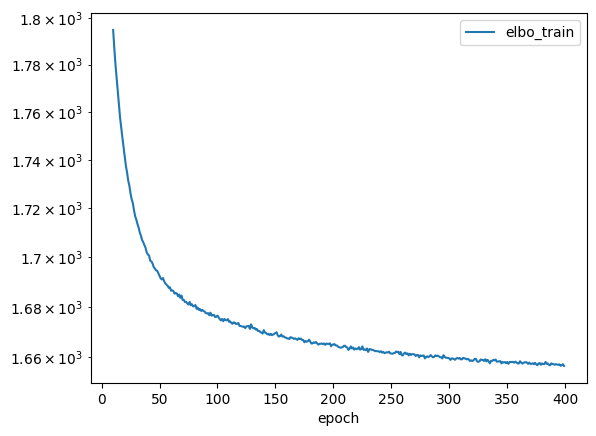

In [15]:
# Show training process
train_test_results = model.history["elbo_train"]
train_test_results.iloc[10:].plot(logy=True)  # exclude first 10 epochs
pyplot.show()

In [17]:
# Difference between the two trajectories

de_change = model.differential_expression(idx1 = (adata.obs["group"] == "Hic2"),
                                          idx2 = (adata.obs["group"] == "control"))
dead_end_tfs = ['Barx2', 'Dmrtc2', 'Hmgb3', 'Hoxa7', 'Myc', 'Ovol1', 'Phox2a',
       'Tlx2', 'Tshz1', 'Zbtb7c']
columns_of_interest = ["proba_m1", "bayes_factor", "raw_mean1", "raw_mean2"]
de_change.loc[dead_end_tfs, columns_of_interest]

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

,proba_m1,bayes_factor,raw_mean1,raw_mean2
gene_names,,,,
Barx2,0.3014,-0.840640,0.064580,0.383067
Dmrtc2,0.1880,-1.463058,0.182940,1.691815
Hmgb3,0.2420,-1.141746,0.943144,2.391465
Hoxa7,0.3024,-0.835895,0.582325,0.935048
Myc,0.3360,-0.681171,2.682554,4.551935
Ovol1,0.1384,-1.828643,0.069429,0.664535
Phox2a,0.2942,-0.875072,0.297553,0.721905
Tlx2,0.1504,-1.731467,0.191095,1.557947
Tshz1,0.3212,-0.748263,0.748517,1.058353


# Differential expression between macrostates

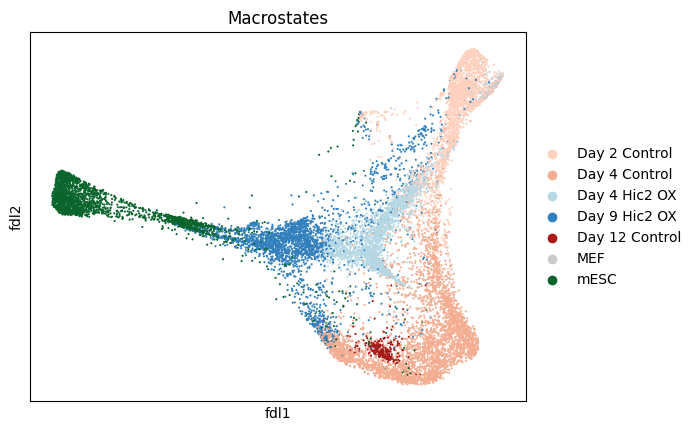

In [18]:
scanpy.pl.embedding(adata, basis="fdl", color="macrostate", title="Macrostates")

In [41]:
# Create model

scvi.model.SCVI.setup_anndata(
    adata,
    layer="raw",
    categorical_covariate_keys=["macrostate"],
    continuous_covariate_keys=["latent_time"]
)

macrostate_model = scvi.model.SCVI(adata)
macrostate_model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [42]:
# Train model

macrostate_model.train(accelerator="gpu", max_epochs=600)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/avesta/m26_losu/miniconda3/envs/scvi/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/avesta/m26_losu/miniconda3/envs/scvi/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: Th

Training:   0%|          | 0/600 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=600` reached.


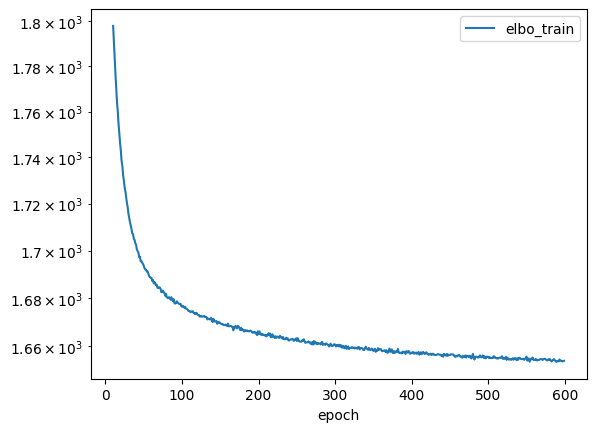

In [43]:
# Show training process
train_test_results = macrostate_model.history["elbo_train"]
train_test_results.iloc[10:].plot(logy=True)  # exclude first 10 epochs
pyplot.show()

In [44]:
# Difference between the two trajectories

de_change = macrostate_model.differential_expression(idx1 = (adata.obs["macrostate"].isin({"Day 4 Hic2 OX", "Day 9 Hic2 OX"})),
                                          idx2 = ~(adata.obs["macrostate"].isin({"Day 4 Hic2 OX", "Day 9 Hic2 OX"})))
dead_end_tfs = ['Barx2', 'Dmrtc2', 'Hmgb3', 'Hoxa7', 'Myc', 'Ovol1', 'Phox2a',
       'Tlx2', 'Tshz1', 'Zbtb7c']
columns_of_interest = ["proba_m1", "bayes_factor", "raw_mean1", "raw_mean2"]
de_change.loc[dead_end_tfs, columns_of_interest]

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

,proba_m1,bayes_factor,raw_mean1,raw_mean2
gene_names,,,,
Barx2,0.5698,0.281035,0.090109,0.222365
Dmrtc2,0.4178,-0.331811,0.209939,0.998002
Hmgb3,0.3816,-0.482763,1.023788,1.720384
Hoxa7,0.4518,-0.193401,0.545655,0.744531
Myc,0.5546,0.219274,2.244616,3.205852
Ovol1,0.4120,-0.355704,0.093913,0.384734
Phox2a,0.5140,0.056015,0.302665,0.450662
Tlx2,0.4262,-0.297372,0.200429,0.921356
Tshz1,0.3974,-0.416310,0.726590,1.026403


In [45]:
# Most upregulated in dead end trajectory

de_change.sort_values("bayes_factor").head(30)[columns_of_interest]

,proba_m1,bayes_factor,raw_mean1,raw_mean2
gene_names,,,,
Megf10,0.1338,-1.867770,0.008559,0.040536
Ddit4l,0.1696,-1.588465,0.172374,0.705979
Mgmt,0.1746,-1.553370,0.281981,0.783898
Uts2b,0.1748,-1.551983,0.000238,0.007921
Igfbp2,0.1754,-1.547829,1.534463,4.120491
Nradd,0.1776,-1.532693,1.136475,3.694822
Emb,0.1780,-1.529957,0.417979,1.397037
Pla2g16,0.1798,-1.517703,0.213744,0.652512
Ankrd12,0.1840,-1.489479,0.600817,1.306290


In [46]:
# Difference between the two day 4 states

de_change = macrostate_model.differential_expression(idx1 = (adata.obs["macrostate"] == "Day 4 Hic2 OX"),
                                          idx2 = (adata.obs["macrostate"] == "Day 4 Control"))
dead_end_tfs = ['Barx2', 'Dmrtc2', 'Hmgb3', 'Hoxa7', 'Myc', 'Ovol1', 'Phox2a',
       'Tlx2', 'Tshz1', 'Zbtb7c']
columns_of_interest = ["proba_m1", "bayes_factor", "raw_mean1", "raw_mean2"]
de_change.loc[dead_end_tfs, columns_of_interest]

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

,proba_m1,bayes_factor,raw_mean1,raw_mean2
gene_names,,,,
Barx2,0.3076,-0.811364,0.047911,0.435753
Dmrtc2,0.1222,-1.971760,0.264067,2.233237
Hmgb3,0.1678,-1.601300,1.191643,2.910644
Hoxa7,0.3758,-0.507414,0.765462,0.958648
Myc,0.3346,-0.687453,3.323129,5.746162
Ovol1,0.0810,-2.428837,0.109749,0.788260
Phox2a,0.2456,-1.122219,0.467410,0.901109
Tlx2,0.0432,-3.097754,0.272424,2.102225
Tshz1,0.3802,-0.488699,1.025630,1.113951


In [47]:
# Most upregulated in day 4 control

de_change.sort_values("bayes_factor").head(20)[columns_of_interest]

,proba_m1,bayes_factor,raw_mean1,raw_mean2
gene_names,,,,
Cd24a,0.0026,-5.949637,2.216158,10.985461
Ptp4a3,0.0028,-5.875328,0.521448,3.672368
Lmo1,0.0096,-4.636345,0.408356,7.226574
S100a16,0.0162,-4.106411,1.352091,9.081874
Nradd,0.0184,-3.976833,0.881341,5.146690
Rtn4r,0.0196,-3.912431,0.096379,2.347773
Mapk13,0.0200,-3.891820,0.064067,0.679325
Kcnn4,0.0226,-3.766946,0.056824,1.966186
Sult2b1,0.0272,-3.576961,0.012256,0.305027


In [48]:
# Specific to the dead end

de_change = macrostate_model.differential_expression(idx1 = (adata.obs["macrostate"] != "Day 12 Control"),
                                          idx2 = (adata.obs["macrostate"] == "Day 12 Control"))
de_change.loc[dead_end_tfs, columns_of_interest]

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

,proba_m1,bayes_factor,raw_mean1,raw_mean2
gene_names,,,,
Barx2,0.1414,-1.803710,0.166907,0.723636
Dmrtc2,0.1732,-1.563116,0.730973,1.098181
Hmgb3,0.6520,0.627842,1.514319,0.443636
Hoxa7,0.3630,-0.562367,0.680636,0.610909
Myc,0.1562,-1.686778,2.834486,5.399996
Ovol1,0.0676,-2.624154,0.264864,1.392726
Phox2a,0.0754,-2.506554,0.383036,1.265454
Tlx2,0.3102,-0.799184,0.683119,0.738181
Tshz1,0.3778,-0.498897,0.935960,0.556363


In [49]:
# Top dead-end specific

de_change.sort_values("bayes_factor").head(30)[columns_of_interest]

,proba_m1,bayes_factor,raw_mean1,raw_mean2
gene_names,,,,
Ppp1r15a,0.0012,-6.724225,1.221961,4.989088
Maff,0.0016,-6.436144,0.237619,1.723635
Dpp7,0.0036,-5.623212,0.531483,2.232726
Sqstm1,0.0044,-5.421739,2.787688,7.650904
Zfand5,0.0058,-5.144079,2.523964,10.156357
Zfas1,0.0060,-5.109976,7.288903,34.047318
Snhg1,0.0066,-5.014062,7.417943,36.581879
1110038B12Rik,0.0074,-4.898846,6.864522,26.767307
1810032O08Rik,0.0086,-4.747355,0.447675,3.239998
